# Earth Intelligence System (EIS)

## Module 01: Location Engine

---

### Author
Shreya Jariwala

### Project
Earth Intelligence System (EIS)

### Version
1.0.0 (Development)

### Purpose

The Location Engine is responsible for transforming user-defined locations into standardized Areas of Interest (AOIs).

It serves as the foundation of the Earth Intelligence System by providing a consistent geographic representation that can be used by all downstream modules, including satellite imagery retrieval, feature extraction, environmental monitoring, and risk assessment.

---

## Objectives

This notebook develops and validates the complete Location Engine workflow.

By the end of this notebook, the Location Engine will be able to:

- Accept different location input types
- Validate user input
- Search geographic locations
- Resolve administrative boundaries
- Retrieve boundary geometries
- Generate standardized AOI objects

---

## Development Workflow

User Input

↓

Input Normalization

↓

Input Validation

↓

Location Search

↓

Candidate Selection

↓

Boundary Resolution

↓

Boundary Retrieval

↓

Geometry Validation

↓

AOI Generation

In [4]:
# Import Required Libraries

from typing import Dict, List, Optional

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from geopy.geocoders import Nominatim

# System Architecture

The Location Engine is designed using a modular architecture.

Each stage of the workflow performs one specific responsibility.

This design improves readability, maintainability, scalability, and testing.

```
Location Engine

├── User Configuration
├── Input Normalization
├── Input Validation
├── Location Search
├── Candidate Selection
├── Boundary Resolution
├── Boundary Retrieval
├── Geometry Validation
└── AOI Generation
```

# User Configuration

## Purpose

The User Configuration defines the geographic location that the Earth Intelligence System (EIS) will analyze.

This component acts as the entry point to the Location Engine by collecting the user's requested study area in a standardized format.

The Location Engine supports multiple input types. Version 1 currently supports location search using a city and country name.

Future versions will support:

- Geographic coordinates
- Bounding boxes
- GeoJSON files
- Shapefiles
- KML files

## Input

A dictionary describing the user's requested location.

## Output

A standardized configuration object that is passed to the next stage of the Location Engine.

In [5]:
# User Configuration

location = {
    "input_type": "city",
    "city": "Mumbai",
    "country": "India"
}

print("USER CONFIGURATION")

for key, value in location.items():
    print(f"{key:<15}: {value}")


USER CONFIGURATION
input_type     : city
city           : Mumbai
country        : India


# Input Normalization

## Purpose

Users may enter the same location in many different ways. Before validation or searching, the input is standardized into a consistent format.

Input normalization improves search reliability and ensures that all downstream components of the Location Engine receive predictable data.

## Input

The `location` configuration object.

## Processing

- Remove leading and trailing whitespace.
- Standardize capitalization.
- Create a standardized search query.

## Output

A normalized location object that is ready for validation.

In [6]:
# Input Normalization

# Create a copy of the original user input
normalized_location = location.copy()

# Normalize city name
normalized_location["city"] = (
    normalized_location["city"]
    .strip()
    .title()
)

# Normalize country name
normalized_location["country"] = (
    normalized_location["country"]
    .strip()
    .title()
)

# Create a standardized search query
normalized_location["search_query"] = (
    f"{normalized_location['city']}, "
    f"{normalized_location['country']}"
)

print("NORMALIZED LOCATION")

for key, value in normalized_location.items():
    print(f"{key:<15}: {value}")


NORMALIZED LOCATION
input_type     : city
city           : Mumbai
country        : India
search_query   : Mumbai, India


# Input Validation

## Purpose

The purpose of input validation is to verify that the user configuration contains all required information before initiating any communication with external geospatial services.

Validating user input early prevents unnecessary API requests, improves error handling, and ensures that downstream components receive complete and consistent information.

## Input

The normalized location object.

## Processing

- Verify the input type is supported.
- Verify required fields are present.
- Verify required fields are not empty.

## Output

A validated location object that is ready for geographic search.

In [7]:
# Input Validation

# Create a copy of the normalized input
validated_location = normalized_location.copy()

# Supported input types
SUPPORTED_INPUT_TYPES = [
    "city"
]

# Validate input type
if validated_location["input_type"] not in SUPPORTED_INPUT_TYPES:
    raise ValueError(
        f"Unsupported input type: {validated_location['input_type']}"
    )

# Validate city
if not validated_location["city"]:
    raise ValueError(
        "City name cannot be empty."
    )

# Validate country
if not validated_location["country"]:
    raise ValueError(
        "Country name cannot be empty."
    )

print("VALIDATED LOCATION")

for key, value in validated_location.items():
    print(f"{key:<15}: {value}")

print("Input validation completed successfully.")

VALIDATED LOCATION
input_type     : city
city           : Mumbai
country        : India
search_query   : Mumbai, India
Input validation completed successfully.


# Location Search

## Purpose

The Location Search component queries a geocoding service to identify geographic locations that match the user's request.

Rather than assuming a single correct result, the Location Engine retrieves all available candidate locations. This allows the system to handle ambiguous place names and select the most appropriate location in a later stage.

## Input

The validated location object.

## Processing

- Submit the search query to the geocoding service.
- Retrieve all matching locations.
- Convert the results into a standardized candidate list.

## Output

A list of candidate locations containing the information required by the downstream components of the Location Engine.

In [8]:
# Location Search

# Create a geocoder
geolocator = Nominatim(user_agent="earth_intelligence_system")

# Search for matching locations
search_results = geolocator.geocode(
    validated_location["search_query"],
    exactly_one=False,
    addressdetails=True
)

if search_results is None:
    raise ValueError(
        f"No locations found for '{validated_location['search_query']}'"
    )

# Convert results into a standardized list
candidate_locations = []

for result in search_results:

    candidate = {
        "name": result.address,
        "latitude": result.latitude,
        "longitude": result.longitude,
        "raw": result.raw
    }

    candidate_locations.append(candidate)

print("LOCATION SEARCH")

print(f"Candidates Found : {len(candidate_locations)}")


LOCATION SEARCH
Candidates Found : 1


# Standardize Candidate Locations

## Purpose

Geocoding providers return different response formats. To ensure that the rest of the Earth Intelligence System remains independent of any specific provider, the Location Engine converts all search results into a standardized candidate format.

This standardized representation becomes the official output of the Location Search component and serves as the input to the Candidate Selection component.

## Input

Raw search results returned by the geocoding service.

## Processing

- Extract essential metadata.
- Remove provider-specific fields.
- Create a standardized candidate representation.

## Output

A list of standardized candidate locations.

In [9]:

# Standardize Candidate Locations

candidate_locations = []

for result in search_results:

    candidate = {

        # User-defined location 
        "city": normalized_location["city"],
        "country": normalized_location["country"],

        # Display information 
        "display_name": result.address,

        # Coordinates 
        "latitude": result.latitude,
        "longitude": result.longitude,

        # OpenStreetMap metadata
        "osm_type": result.raw.get("osm_type"),
        "osm_id": result.raw.get("osm_id"),
        "place_id": result.raw.get("place_id"),
        "class": result.raw.get("class"),
        "type": result.raw.get("type")
    }

    candidate_locations.append(candidate)

print("STANDARDIZED CANDIDATE LOCATIONS")
print(f"Candidates Found : {len(candidate_locations)}")

STANDARDIZED CANDIDATE LOCATIONS
Candidates Found : 1


# Candidate Selection

## Purpose

The Location Search component may return one or more candidate locations.

The Candidate Selection component determines which candidate will be used by the Location Engine.

Version 1 automatically selects the highest-ranked candidate returned by the geocoding service.

Future versions will support:

- Interactive user selection
- Confidence scoring
- Automatic ranking using multiple criteria

## Input

A list of standardized candidate locations.

## Output

A single selected location.

In [10]:
# Candidate Selection

selected_location = candidate_locations[0]

print("SELECTED LOCATION")

for key, value in selected_location.items():
    print(f"{key:<15}: {value}")


SELECTED LOCATION
city           : Mumbai
country        : India
display_name   : Mumbai, Mumbai Suburban District, Maharashtra, 400051, India
latitude       : 19.054999
longitude      : 72.8692035
osm_type       : node
osm_id         : 16173235
place_id       : 246861342
class          : place
type           : city


# AOI (Area of Interest) Data Model

## Purpose

The Area of Interest (AOI) is the standard geographic object used throughout the Earth Intelligence System.

Regardless of how a user defines a study area (city, coordinates, GeoJSON, shapefile, etc.), the Location Engine converts the input into a standardized AOI.

Every downstream engine—including satellite imagery retrieval, feature extraction, environmental monitoring, and risk assessment—uses the AOI as its input.

The AOI acts as the common language between all modules of the Earth Intelligence System.

## Design Principles

- Independent of the input format
- Independent of the geocoding provider
- Independent of the Earth observation provider
- Reusable across all EIS modules
- Easily extendable

In [11]:
# AOI Data Model

aoi = {

  
    # Identity
  
    "identity": {

        "name": None,
        "country": None

    },

    # Input Information
  
    "input": {

        "input_type": None,
        "user_input": None,
        "search_query": None

    },

    # Location Information

    "location": {

        "latitude": None,
        "longitude": None

    },


    # Geometry

    "geometry": {

        "geometry": None,
        "geometry_type": None

    },

    # Spatial Properties

   "spatial": {
    "bounding_box": None,
    "centroid": None,
    "area_sq_km": None,
    "perimeter_km": None
    },

    # Coordinate Reference System

    "crs": "EPSG:4326",

    # Metadata

    "metadata": {

        "provider": None,
        "created_at": None

    }

}

print("AOI data model initialized successfully.")

AOI data model initialized successfully.


# AOI Population (Stage 1)

## Purpose

The AOI is populated incrementally as information becomes available.

At this stage, the Location Engine already knows the user's request and the selected geographic location. These attributes are transferred into the AOI before retrieving the administrative boundary geometry.

Geometry and spatial properties will be populated in later stages.

In [12]:
# AOI Population (Stage 1)

from datetime import datetime

# Identity

aoi["identity"]["name"] = selected_location["display_name"]
aoi["identity"]["country"] = location["country"]

# Input

aoi["input"]["input_type"] = location["input_type"]
aoi["input"]["user_input"] = location.copy()
aoi["input"]["search_query"] = normalized_location["search_query"]

# Location

aoi["location"]["latitude"] = selected_location["latitude"]
aoi["location"]["longitude"] = selected_location["longitude"]

# Metadata

aoi["metadata"]["provider"] = "OpenStreetMap (Nominatim)"
aoi["metadata"]["created_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("AOI populated successfully.")

AOI populated successfully.


# Boundary Provider

## Purpose

The Boundary Provider retrieves the administrative boundary geometry associated with the selected location.

Unlike the Search Provider, which resolves a place name into a geographic location, the Boundary Provider retrieves the polygon defining the Area of Interest (AOI).

The Earth Intelligence System is designed to be provider-independent. Version 1 uses GeoBoundaries as the default administrative boundary provider.

## Input

- Selected Location

## Output

- Boundary Geometry

In [13]:
# Boundary Provider Configuration

BOUNDARY_PROVIDER = {

    "name": "GeoBoundaries",

    "version": "v5",

    "boundary_level": "ADM2",

    "crs": "EPSG:4326"

}

print("BOUNDARY PROVIDER")

for key, value in BOUNDARY_PROVIDER.items():
    print(f"{key:<18}: {value}")


BOUNDARY PROVIDER
name              : GeoBoundaries
version           : v5
boundary_level    : ADM2
crs               : EPSG:4326


In [14]:
# Boundary Provider Interface

class BoundaryProvider:
    """
    Base class for all boundary providers used by the
    Earth Intelligence System.
    """

    def __init__(self, provider_name):

        self.provider_name = provider_name

    def get_boundary(self, selected_location):

        raise NotImplementedError(
            "Boundary providers must implement get_boundary()."
        )

In [15]:
# GeoBoundaries Provider

class GeoBoundariesProvider(BoundaryProvider):

    def __init__(self):

        super().__init__("GeoBoundaries")

    def get_boundary(self, selected_location):

        print("BOUNDARY PROVIDER")

        print(f"Provider : {self.provider_name}")

        print(
            f"Searching boundary for:\n"
            f"{selected_location['display_name']}"
        )

        # Retrieval logic will be implemented later

        return None

In [16]:
provider = GeoBoundariesProvider()

provider.get_boundary(selected_location)

BOUNDARY PROVIDER
Provider : GeoBoundaries
Searching boundary for:
Mumbai, Mumbai Suburban District, Maharashtra, 400051, India


# Country Resolution

## Purpose

Boundary datasets are organized using standardized country codes rather than country names.

This component converts the selected country's name into its corresponding ISO 3166-1 Alpha-3 code.

The ISO3 code is then used by the Boundary Provider to locate the correct administrative boundary dataset.

In [18]:
# Country Resolution

import pycountry

country_name = aoi["identity"]["country"]

country = pycountry.countries.lookup(country_name)

if country is None:
    raise ValueError(f"Unknown country: {country_name}")

iso3 = country.alpha_3

print("COUNTRY RESOLUTION")

print(f"Country : {country_name}")
print(f"ISO3    : {iso3}")


COUNTRY RESOLUTION
Country : India
ISO3    : IND


# Administrative Level Selection

## Purpose

Administrative boundaries are organized into hierarchical levels (ADM0, ADM1, ADM2, etc.).

This component determines which administrative level should be retrieved based on the user's requested study area.

Version 1 uses a configurable administrative level to ensure consistent boundary retrieval across different countries.

## Input

- Boundary Provider Configuration

## Output

- Selected Administrative Level

In [19]:
# Administrative Level Selection

# Default administrative level
admin_level = BOUNDARY_PROVIDER["boundary_level"]

SUPPORTED_LEVELS = [
    "ADM0",
    "ADM1",
    "ADM2",
    "ADM3",
    "ADM4",
    "ADM5"
]

if admin_level not in SUPPORTED_LEVELS:
    raise ValueError(
        f"Unsupported administrative level: {admin_level}"
    )


print("ADMINISTRATIVE LEVEL")

print(f"Selected Level : {admin_level}")


ADMINISTRATIVE LEVEL
Selected Level : ADM2


# Geometry Retrieval

## Purpose

The Geometry Retrieval component uses the configured Boundary Provider to retrieve the administrative boundary geometry for the selected location.

The returned geometry is stored as a GeoDataFrame and serves as the spatial representation of the Area of Interest (AOI).

## Input

- Selected Location
- Country ISO3 Code
- Administrative Level

## Output

- Boundary GeoDataFrame

In [20]:
# GeoBoundaries Provider

import requests


class GeoBoundariesProvider(BoundaryProvider):

    def __init__(self):

        super().__init__("GeoBoundaries")

    def get_boundary(self, country_iso3, admin_level):

        print("BOUNDARY PROVIDER")

        levels_to_try = [
            admin_level,
            "ADM1",
            "ADM0"
        ]

        # Remove duplicates while preserving order
        levels_to_try = list(dict.fromkeys(levels_to_try))

        for level in levels_to_try:

            api_url = (
                "https://www.geoboundaries.org/api/current/"
                f"gbOpen/{country_iso3}/{level}/"
            )

            print(f"\nTrying {level}...")

            response = requests.get(api_url)

            if response.status_code == 200:

                print(f"✓ Using {level}")

                metadata = response.json()

                metadata["selected_level"] = level

                return metadata

            print(f"✗ {level} not available.")

        raise ValueError(
            f"No administrative boundary dataset found for {country_iso3}."
        )

In [21]:
provider = GeoBoundariesProvider()

metadata = provider.get_boundary(
    country_iso3=iso3,
    admin_level=admin_level
)

BOUNDARY PROVIDER

Trying ADM2...
✓ Using ADM2


In [22]:
metadata.keys()

dict_keys(['boundaryID', 'boundaryName', 'boundaryISO', 'boundaryYearRepresented', 'boundaryType', 'boundaryCanonical', 'boundarySource', 'boundaryLicense', 'licenseDetail', 'licenseSource', 'boundarySourceURL', 'sourceDataUpdateDate', 'buildDate', 'Continent', 'UNSDG-region', 'UNSDG-subregion', 'worldBankIncomeGroup', 'admUnitCount', 'meanVertices', 'minVertices', 'maxVertices', 'meanPerimeterLengthKM', 'minPerimeterLengthKM', 'maxPerimeterLengthKM', 'meanAreaSqKM', 'minAreaSqKM', 'maxAreaSqKM', 'staticDownloadLink', 'gjDownloadURL', 'tjDownloadURL', 'imagePreview', 'simplifiedGeometryGeoJSON', 'selected_level'])

In [23]:
# Boundary Dataset Loading

download_url = metadata["gjDownloadURL"]

print("DOWNLOADING BOUNDARY DATASET")
print(download_url)

boundary_gdf = gpd.read_file(download_url)

print("\n✓ Dataset loaded successfully!")
print(f"Number of Features : {len(boundary_gdf)}")
print(f"CRS                : {boundary_gdf.crs}")
print(f"Geometry Type      : {boundary_gdf.geometry.iloc[0].geom_type}")

DOWNLOADING BOUNDARY DATASET
https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/IND/ADM2/geoBoundaries-IND-ADM2.geojson

✓ Dataset loaded successfully!
Number of Features : 735
CRS                : EPSG:4326
Geometry Type      : Polygon


In [24]:
boundary_gdf.head()

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Ashoknagar,,76128533B75548370501185,IND,ADM2,"POLYGON ((78.17491 24.84254, 78.17466 24.84194..."
1,Raisen,,76128533B57893545331548,IND,ADM2,"POLYGON ((77.38167 23.07004, 77.38094 23.0698,..."
2,Chhindwara,,76128533B70646408240587,IND,ADM2,"POLYGON ((79.23988 22.79135, 79.24 22.79172, 7..."
3,Betul,,76128533B82559220423608,IND,ADM2,"POLYGON ((78.27229 22.39973, 78.27169 22.39897..."
4,Hoshangabad,,76128533B45314020251888,IND,ADM2,"POLYGON ((78.03027 22.79953, 78.02986 22.79969..."


In [25]:
boundary_gdf.columns.tolist()

['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']

# Boundary Selection

## Purpose

The administrative boundary dataset contains multiple geographic features.

This component identifies the feature corresponding to the selected location and extracts its geometry.

The selected feature becomes the Area of Interest (AOI) for the Earth Intelligence System.

## Input

- Boundary Dataset
- Selected Location

## Output

- AOI Boundary

In [26]:
# Search Administrative Units

search_term = selected_location["city"]

matches = boundary_gdf[
    boundary_gdf["shapeName"].str.contains(
        search_term,
        case=False,
        na=False
    )
]

print("MATCHING ADMINISTRATIVE UNITS")

print(matches[["shapeName", "shapeType"]])

print("\nMatches Found:", len(matches))

MATCHING ADMINISTRATIVE UNITS
           shapeName shapeType
480           Mumbai      ADM2
481  Mumbai Suburban      ADM2

Matches Found: 2


# Boundary Resolution

## Purpose

The selected location may correspond to multiple administrative boundaries within the selected administrative level.

This component resolves ambiguities by identifying all matching administrative units.

If:
- one match is found → continue automatically.
- multiple matches are found → request user selection.
- no matches are found → raise an error.

In [27]:
# Boundary Resolution

search_term = selected_location["city"]
matches = boundary_gdf[
    boundary_gdf["shapeName"].str.contains(
        search_term,
        case=False,
        na=False
    )
].reset_index(drop=True)

print("BOUNDARY RESOLUTION")


if len(matches) == 0:

    raise ValueError(
        f"No administrative boundary found for '{search_term}'."
    )

elif len(matches) == 1:

    print("One matching boundary found.")
    selected_boundary = matches.iloc[0]

else:

    print(f"Multiple matching boundaries found ({len(matches)}).\n")

    for idx, row in matches.iterrows():
        print(f"{idx + 1}. {row['shapeName']}")

    print("\nPlease select one of the above boundaries.")

BOUNDARY RESOLUTION
Multiple matching boundaries found (2).

1. Mumbai
2. Mumbai Suburban

Please select one of the above boundaries.


In [28]:
selected_location

{'city': 'Mumbai',
 'country': 'India',
 'display_name': 'Mumbai, Mumbai Suburban District, Maharashtra, 400051, India',
 'latitude': 19.054999,
 'longitude': 72.8692035,
 'osm_type': 'node',
 'osm_id': 16173235,
 'place_id': 246861342,
 'class': 'place',
 'type': 'city'}

# Boundary Selection

## Purpose

When multiple administrative boundaries match the selected location, the user selects the desired boundary.

In Version 1, the selection is made manually using the index of the matching feature.

Future versions may support automatic ranking or an interactive interface.

In [29]:
# Boundary Selection


# Version 1:
# Change this value if another boundary should be selected.

if len(matches) == 1:
    selected_boundary_index = 0
else:
    print("\nAvailable boundaries:")
    for i, row in matches.iterrows():
        print(f"{i}: {row['shapeName']}")
    selected_boundary_index = int(input("\nSelect boundary index: "))

selected_boundary = matches.iloc[selected_boundary_index]

print("SELECTED BOUNDARY")

print(f"Name : {selected_boundary['shapeName']}")
print(f"Type : {selected_boundary['shapeType']}")
print(f"ID   : {selected_boundary['shapeID']}")


Available boundaries:
0: Mumbai
1: Mumbai Suburban
SELECTED BOUNDARY
Name : Mumbai
Type : ADM2
ID   : 76128533B16442413169750


In [30]:
# AOI Boundary

aoi_boundary = matches.iloc[[selected_boundary_index]].copy()

print("AOI BOUNDARY")

print(f"Features : {len(aoi_boundary)}")
print(f"Geometry : {aoi_boundary.geometry.iloc[0].geom_type}")
print(f"CRS      : {aoi_boundary.crs}")

AOI BOUNDARY
Features : 1
Geometry : MultiPolygon
CRS      : EPSG:4326


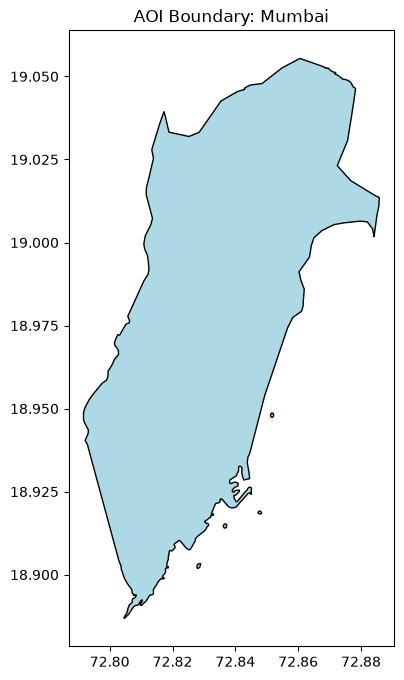

In [31]:
# AOI Visualization

ax = aoi_boundary.plot(
    figsize=(8, 8),
    edgecolor="black",
    facecolor="lightblue"
)

ax.set_title(f"AOI Boundary: {aoi_boundary.iloc[0]['shapeName']}")

plt.show()

# Bounding Box Computation

## Purpose

Compute the minimum bounding rectangle (bounding box) of the Area of Interest (AOI).

The bounding box provides a compact spatial extent that is commonly used for:

- Spatial indexing
- Satellite imagery requests
- Raster clipping
- Web map visualization
- API queries

## Output

- Minimum Longitude
- Minimum Latitude
- Maximum Longitude
- Maximum Latitude

In [32]:

# Bounding Box Computation

minx, miny, maxx, maxy = aoi_boundary.total_bounds

bbox = {
    "min_longitude": float(minx),
    "min_latitude": float(miny),
    "max_longitude": float(maxx),
    "max_latitude": float(maxy)
}

print("BOUNDING BOX")


for key, value in bbox.items():
    print(f"{key:<15}: {value:.6f}")

BOUNDING BOX
min_longitude  : 72.791670
min_latitude   : 18.886840
max_longitude  : 72.885840
max_latitude   : 19.055430


# Bounding Box Visualization

## Purpose

Visualize the AOI together with its bounding box.

This provides a quick visual verification that the computed bounding box fully encloses the selected administrative boundary.

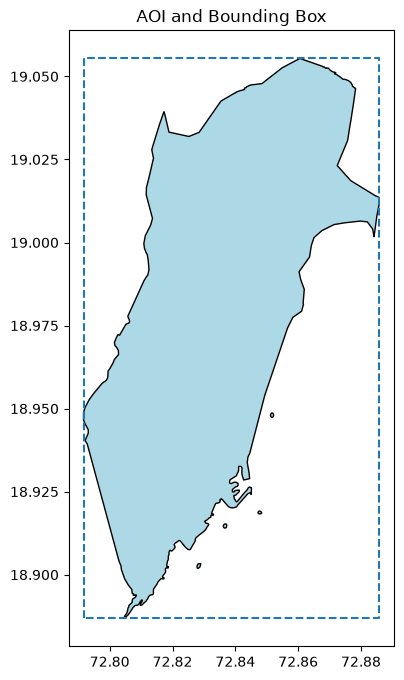

In [33]:
# Bounding Box Visualization

from shapely.geometry import box

bounding_box = box(minx, miny, maxx, maxy)

bbox_gdf = gpd.GeoDataFrame(
    geometry=[bounding_box],
    crs=aoi_boundary.crs
)

ax = aoi_boundary.plot(
    figsize=(8, 8),
    edgecolor="black",
    facecolor="lightblue"
)

bbox_gdf.boundary.plot(
    ax=ax,
    linestyle="--"
)

ax.set_title("AOI and Bounding Box")

plt.show()

# Centroid Computation

## Purpose

Compute the centroid of the Area of Interest (AOI).

The centroid represents the geometric center of the selected boundary and is commonly used for:

- Map centering
- Spatial indexing
- Label placement
- Initial camera/view positioning
- Location-based API requests

## Note

The centroid is computed in the current Coordinate Reference System (EPSG:4326). Since this CRS uses geographic coordinates (latitude and longitude), GeoPandas will issue a warning. For the purposes of map centering and visualization, this is acceptable.

When precise geometric calculations are required, the geometry should first be projected to an appropriate projected CRS.

In [34]:
# Centroid Computation

centroid = aoi_boundary.geometry.centroid.iloc[0]

print("CENTROID")

print(f"Longitude : {centroid.x:.6f}")
print(f"Latitude  : {centroid.y:.6f}")

CENTROID
Longitude : 72.833804
Latitude  : 18.980765


/var/folders/5_/cvzq6ppx5618gh2wl_k6nbww0000gp/T/ipykernel_60334/2763472472.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = aoi_boundary.geometry.centroid.iloc[0]


# Centroid Visualization

## Purpose

Visualize the centroid together with the Area of Interest.

This provides a visual confirmation that the centroid lies within (or near the center of) the selected boundary.

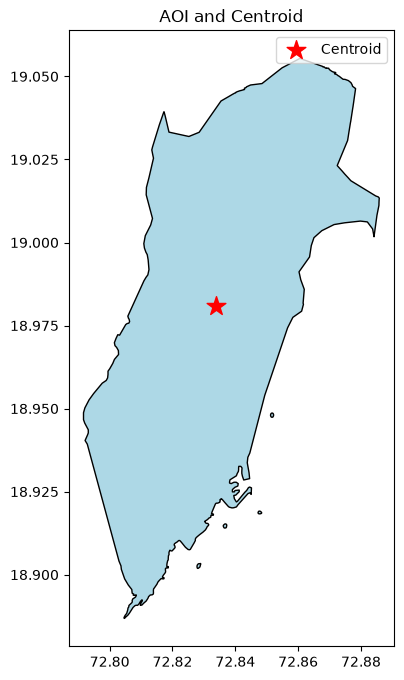

In [35]:
# Centroid Visualization

centroid_gdf = gpd.GeoDataFrame(
    geometry=[centroid],
    crs=aoi_boundary.crs
)

ax = aoi_boundary.plot(
    figsize=(8, 8),
    edgecolor="black",
    facecolor="lightblue"
)

centroid_gdf.plot(
    ax=ax,
    marker="*",
    markersize=200,
    color="red",
    label="Centroid"
)

plt.legend()

ax.set_title("AOI and Centroid")

plt.show()

# Area and Perimeter Computation

## Purpose

Compute the physical area and perimeter of the Area of Interest (AOI).

To ensure accurate geometric measurements, the AOI is first projected from the geographic coordinate system (EPSG:4326) into an appropriate projected Coordinate Reference System (CRS).

The resulting measurements are reported in:

- Square Kilometers (km²)
- Kilometers (km)

In [36]:
# Determine Projected CRS

projected_crs = aoi_boundary.estimate_utm_crs()

print("PROJECTED CRS")

print(projected_crs)

PROJECTED CRS
EPSG:32643


In [37]:

# Project AOI


aoi_projected = aoi_boundary.to_crs(projected_crs)

print("AOI PROJECTION")

print(f"Original CRS  : {aoi_boundary.crs}")
print(f"Projected CRS : {aoi_projected.crs}")

AOI PROJECTION
Original CRS  : EPSG:4326
Projected CRS : EPSG:32643


In [38]:
# Area and Perimeter

area_sq_m = aoi_projected.geometry.area.iloc[0]

perimeter_m = aoi_projected.geometry.length.iloc[0]

area_sq_km = area_sq_m / 1_000_000

perimeter_km = perimeter_m / 1000

print("AREA AND PERIMETER")

print(f"Area      : {area_sq_km:,.2f} km²")
print(f"Perimeter : {perimeter_km:,.2f} km")

AREA AND PERIMETER
Area      : 87.70 km²
Perimeter : 57.72 km


# Why Projection Matters

The Area of Interest is stored in EPSG:4326 because it is the standard geographic coordinate system used by GPS, OpenStreetMap, GeoJSON, and most web mapping applications.

However, geometric measurements such as area and perimeter require a projected coordinate system where distances are expressed in meters.

The AOI is therefore temporarily projected into an appropriate Universal Transverse Mercator (UTM) coordinate system before performing these calculations.

# AOI Population (Stage 2)

## Purpose

Populate the remaining spatial attributes of the Area of Interest (AOI).

At this stage, all geometric properties have been computed and are consolidated into the AOI object.

The AOI becomes the standardized geographic representation that will be consumed by all downstream Earth Intelligence System modules.

## Spatial Attributes

- Geometry
- Geometry Type
- Coordinate Reference System
- Bounding Box
- Centroid
- Area
- Perimeter

In [39]:
# AOI Population (Stage 2)

# Retrieve geometry from AOI Boundary
geometry = aoi_boundary.geometry.iloc[0]

# Geometry Information
aoi["geometry"]["geometry"] = geometry
aoi["geometry"]["geometry_type"] = geometry.geom_type

# Coordinate Reference System
aoi["geometry"]["crs"] = str(aoi_boundary.crs)

# Bounding Box
aoi["spatial"]["bounding_box"] = bbox

# Centroid
aoi["spatial"]["centroid"] = {
    "longitude": centroid.x,
    "latitude": centroid.y
}

# Area & Perimeter
aoi["spatial"]["area_sq_km"] = float(area_sq_km)
aoi["spatial"]["perimeter_km"] = float(perimeter_km)

print("AOI POPULATION COMPLETE")

print("✓ Geometry")
print("✓ CRS")
print("✓ Bounding Box")
print("✓ Centroid")
print("✓ Area")
print("✓ Perimeter")

AOI POPULATION COMPLETE
✓ Geometry
✓ CRS
✓ Bounding Box
✓ Centroid
✓ Area
✓ Perimeter


# AOI Summary

## Purpose

Display a concise summary of the completed Area of Interest.

This summary provides a quick verification of the Location Engine output before passing the AOI to downstream Earth Intelligence System modules.

In [40]:
# AOI Summary

print("AREA OF INTEREST (AOI)")

print("\nLOCATION")

print(f"Location          : {aoi['identity']['name']}")
print(f"Country           : {aoi['identity']['country']}")

print("\nGEOMETRY")

print(f"Geometry Type     : {aoi['geometry']['geometry_type']}")
print(f"Coordinate System : {aoi['geometry']['crs']}")

print("\nSPATIAL PROPERTIES")

print(f"Area (km²)        : {aoi['spatial']['area_sq_km']:.2f}")
print(f"Perimeter (km)    : {aoi['spatial']['perimeter_km']:.2f}")

print("\nBOUNDING BOX")

for key, value in aoi["spatial"]["bounding_box"].items():
    print(f"{key:<18}: {value:.6f}")

print("\nCENTROID")

print(f"Longitude         : {aoi['spatial']['centroid']['longitude']:.6f}")
print(f"Latitude          : {aoi['spatial']['centroid']['latitude']:.6f}")

AREA OF INTEREST (AOI)

LOCATION
Location          : Mumbai, Mumbai Suburban District, Maharashtra, 400051, India
Country           : India

GEOMETRY
Geometry Type     : MultiPolygon
Coordinate System : EPSG:4326

SPATIAL PROPERTIES
Area (km²)        : 87.70
Perimeter (km)    : 57.72

BOUNDING BOX
min_longitude     : 72.791670
min_latitude      : 18.886840
max_longitude     : 72.885840
max_latitude      : 19.055430

CENTROID
Longitude         : 72.833804
Latitude          : 18.980765


# Export Area of Interest

## Purpose

Export the completed Area of Interest (AOI) to a GeoJSON file.

The exported AOI serves as the standardized input for downstream Earth Intelligence System modules.

Output:

- data/outputs/aoi.geojson

In [41]:
# Export AOI

from pathlib import Path
import geopandas as gpd

output_dir = Path("/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "aoi.geojson"

export_gdf = aoi_boundary.copy()

export_gdf["location"] = aoi["identity"]["name"]
export_gdf["country"] = aoi["identity"]["country"]
export_gdf["area_sq_km"] = aoi["spatial"]["area_sq_km"]
export_gdf["perimeter_km"] = aoi["spatial"]["perimeter_km"]

export_gdf.to_file(
    output_file,
    driver="GeoJSON"
)

print("AOI EXPORTED")

print(output_file.resolve())

AOI EXPORTED
/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs/aoi.geojson
